In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("spambase_csv.csv")

In [2]:
df.head()
df.info()
df.describe()
df.columns
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

(4601, 58)

In [3]:
df.columns

Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_table', 'word_freq_conference',


In [11]:
numeric_col=df.select_dtypes(
include=['int64', 'float64']
).columns.tolist()

binary_col = [col for col in df.columns if df[col].nunique() == 2]

cat_col = df.select_dtypes(include='object').columns.tolist()

print(numeric_col)
print(binary_col)
print(cat_col)

['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char_freq_%21', 'char_freq_%24', 'char_freq_%

In [7]:
df.isnull().sum()
df.fillna(df.mean(),inplace=True)

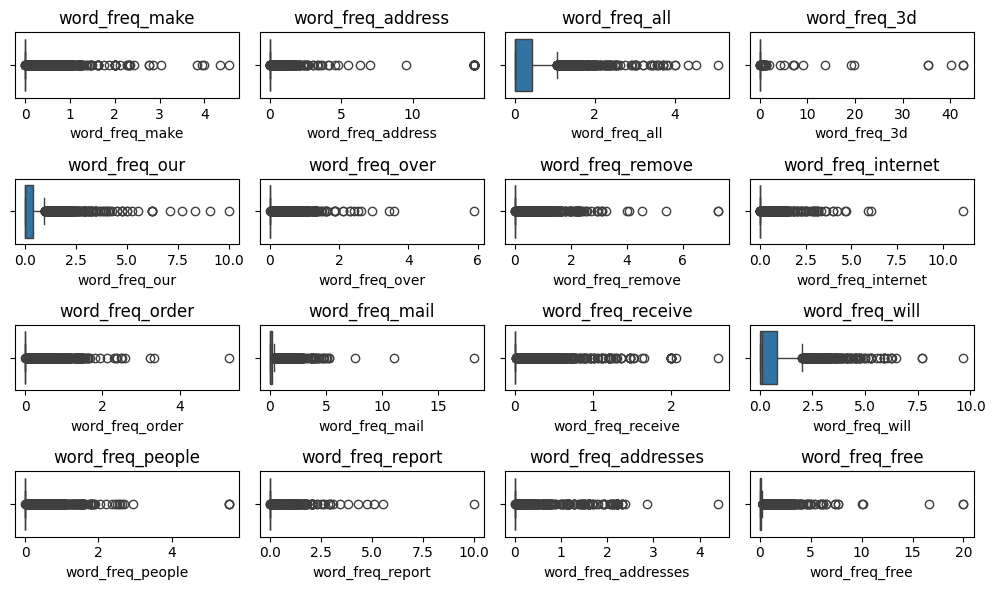

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
nrows=4, ncols=4,
figsize=(10, 6)
)

axes=axes.flatten()

count=0
for i in numeric_col:
    sns.boxplot(data=df,x=i,ax=axes[count])
    axes[count].set_title(i)
    count+=1
    if count==len(axes):
        break

plt.tight_layout()
plt.show()

<Axes: >

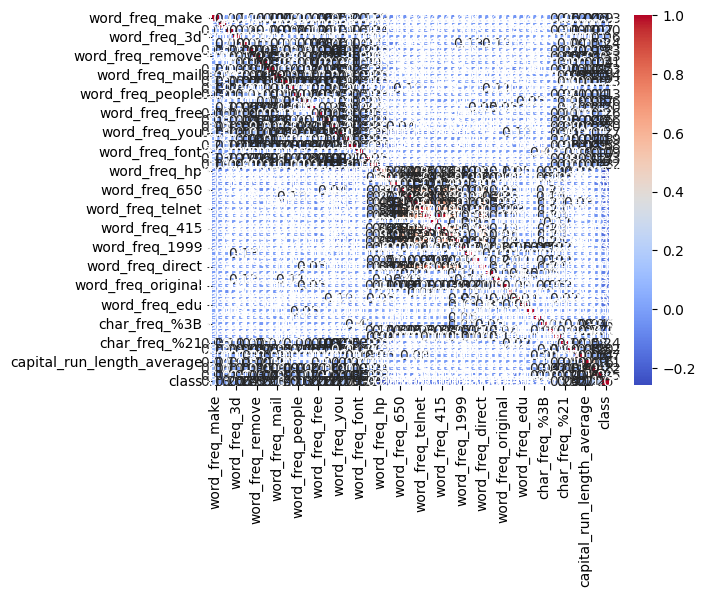

In [19]:
corr=df.corr()

sns.heatmap(corr, annot=True, fmt=".2f",
cmap="coolwarm")

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler, RobustScaler

X_std = StandardScaler().fit_transform(df.drop(columns=['class'],inplace=False))
y=df['class']

print(y)

0       1
1       1
2       1
3       1
4       1
       ..
4596    0
4597    0
4598    0
4599    0
4600    0
Name: class, Length: 4601, dtype: int64


In [25]:
from sklearn.preprocessing import LabelBinarizer
lb = LabelBinarizer(
neg_label=0, pos_label=1, sparse_output=False
)

y_bin = lb.fit_transform(df['class'])
print(y_bin)


[[1]
 [1]
 [1]
 ...
 [0]
 [0]
 [0]]


In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X_std, y_bin, test_size=0.3, random_state=42, stratify=y_bin
)

In [31]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors  import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=3, algorithm=
"ball_tree")

In [33]:
knn.fit(X_train,y_train)

C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(algorithm='ball_tree', n_neighbors=3)

In [34]:
y_pred = knn.predict(X_test)

In [35]:
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
confusion_matrix, classification_report, roc_auc_score,
roc_curve, average_precision_score
)

print(accuracy_score(y_test, y_pred))

0.8986241853729182


In [41]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid={
    'n_neighbors':[3,5,10,15],
    'algorithm':['auto','ball_tree','kd_tree']
}

search=GridSearchCV(estimator=KNeighborsClassifier(),
param_grid=param_grid,
cv=3,
scoring='accuracy',
n_jobs=-1)

In [42]:
search.fit(X_train,y_train)


C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree'],
                         'n_neighbors': [3, 5, 10, 15]},
             scoring='accuracy')

In [43]:
search.best_estimator_

KNeighborsClassifier(n_neighbors=3)

In [44]:
search.cv_results_
search.best_score_
search.best_params_

{'algorithm': 'auto', 'n_neighbors': 3}

In [46]:
search.cv_results_
search.best_score_

0.8962772250192786

In [47]:
search.cv_results_

{'mean_fit_time': array([0.0048267 , 0.00511861, 0.0051887 , 0.00567659, 0.01977762,
        0.01800831, 0.01333316, 0.01585746, 0.03469563, 0.02782941,
        0.02983928, 0.02773396]),
 'std_fit_time': array([0.00024831, 0.00073959, 0.00024074, 0.00023007, 0.00317573,
        0.00078581, 0.00048013, 0.00210389, 0.00833451, 0.00047019,
        0.00170357, 0.00250769]),
 'mean_score_time': array([0.25961002, 0.25285578, 0.25789905, 0.2596426 , 0.30492036,
        0.31979219, 0.27415578, 0.33389823, 0.30253267, 0.3097326 ,
        0.27698628, 0.18700496]),
 'std_score_time': array([0.01495621, 0.01072603, 0.01162916, 0.01017787, 0.01626468,
        0.02153311, 0.01680335, 0.00944803, 0.02551621, 0.02292665,
        0.06245389, 0.0064507 ]),
 'param_algorithm': masked_array(data=['auto', 'auto', 'auto', 'auto', 'ball_tree',
                    'ball_tree', 'ball_tree', 'ball_tree', 'kd_tree',
                    'kd_tree', 'kd_tree', 'kd_tree'],
              mask=[False, False, False, F

In [57]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate,StratifiedKFold
kf=KFold(n_splits=5, shuffle=True, random_state=42)

score1=cross_val_score(estimator=KNeighborsClassifier(),
X=X_train, y=y_train,
cv=kf, scoring='accuracy')

C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was e

In [58]:
print(score1)

[0.92080745 0.88819876 0.88664596 0.89130435 0.91304348]


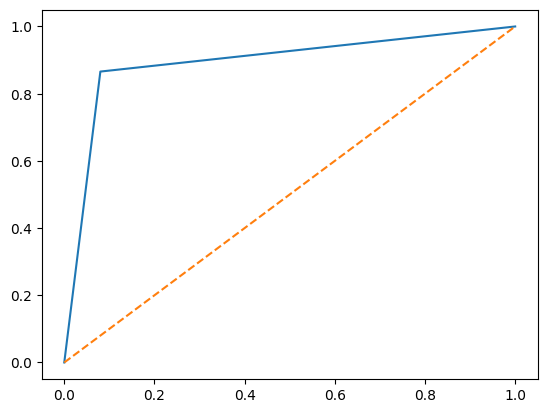

In [54]:
fpr, tpr, thr = roc_curve(y_test,y_pred)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1], linestyle="--")

In [59]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate,StratifiedKFold
kf=KFold(n_splits=5, shuffle=True, random_state=42)

score=cross_val_score(estimator=GaussianNB(),
X=X_train, y=y_train,
cv=kf, scoring='accuracy')

C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\Asus Vivobook\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expecte

In [60]:
score

array([0.81677019, 0.84161491, 0.80745342, 0.8121118 , 0.78571429])

In [69]:
from scipy.stats import friedmanchisquare, f_oneway
model_scores = [score,score1,score]




In [70]:
friedman_stat, friedman_p = friedmanchisquare(*model_scores)
if friedman_p < 0.05:
    print("Significant difference among models | proceed with post-hoc test")
else:
    print("No significant difference | all models perform similarly")

Significant difference among models | proceed with post-hoc test


In [62]:
anova_stat, anova_p = f_oneway(*model_scores)

if anova_p < 0.05:
    print("At least one model differs significantly")
else:
    print("No significant difference detected")

At least one model differs significantly
